In [1]:
import os
import json
# import cv2
import numpy as np
import torch
import glob


In [2]:

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [3]:
class_dict = {
    'Head': 0,
    'RShoulder': 1,
    'LShoulder': 2,
    'LElbow': 3,
    'LWrist': 4,
    'RHip': 5,
    'LHip': 6,
    'LKnee': 7,
    'RKnee': 8,
    'RAnkle': 9,
    'LAnkle': 10,
    'RElbow': 11,
    'RWrist': 12,
    'Neck': 13
}

In [22]:
def Json_to_yolo_formate(json_data):
    yolo_data = []
    for shape in json_data['shapes']:
        x1, y1 = shape['points'][0]
        x2, y2 = shape['points'][1]
        x_center = (x1 + x2) / 2
        y_center = (y1 + y2) / 2
        width = x2 - x1
        height = y2 - y1
        class_id = class_dict[shape['label']]
        yolo_data.append([class_id, x_center, y_center, width, height])
    return yolo_data

def save_yolo_formate(json_data):
    yolo_data = Json_to_yolo_formate(json_data)
    image_name = json_data['imagePath'].split('.')[0]
    directory = './dataset/annotation/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    with open (f'{directory}{image_name}.txt', 'w') as f:
        for data in yolo_data:
            f.write(' '.join(map(str, data)) + '\n')

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2

normal_size = (128,128)

def load_image(path):
    return cv2.imread(path)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def crop_image(image, coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    return image[int(y1):int(y2), int(x1):int(x2)]

def show_image_detail(image, json):
    plt.imshow(image)
    fig, axs = plt.subplots(1, len(json['shapes']), figsize=(15, 15))
    for i, shape in enumerate(json['shapes']):
        croped_test_img = crop_image(image, shape['points'])
        croped_test_img = resize_image(croped_test_img)
        print(croped_test_img.shape)
        axs[i].imshow(croped_test_img)
        axs[i].set_title(shape['label'])
    plt.show()

def resize_image(image, size=normal_size):
    return cv2.resize(image, size)

def vaildate_yolo_formate(path):
    imag = cv2.imread(path)
    yolo_path = os.path.join('dataset', 'annotation', os.path.basename(path).split('.')[0] + '.txt')
    with open(yolo_path, 'r') as boxes:
        for box in boxes:
            box = box.split(' ')
            class_id, x_center, y_center, width, height = map(float, box)
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            cv2.rectangle(imag, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(imag, str(int(class_id)), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    plt.imshow(imag)
    plt.show()

In [25]:
# json_paths = glob.glob('dataset/*.json')
# for json_path in json_paths:
#     json_data = load_json(json_path)
#     save_yolo_formate(json_data)

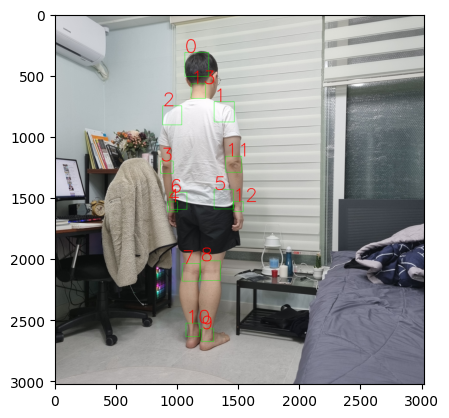

In [26]:
vaildate_yolo_formate('dataset/stand_b_74.png')

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
class backDataset(Dataset):
    def __init__(self, transform=None):
        self.img_paths = glob.glob('dataset/*.png')
        self.transform = transform
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        original_h, original_w = img.shape[:2]
        boxes = []
        normalize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((1920, 1920)),
            transforms.ToTensor()
        ])
        with open(os.path.join('dataset', 'annotation', os.path.basename(self.img_paths[idx]).replace('.png', '.txt'))) as f:
            for line in f.readlines():
                class_id, center_x, center_y, w, h = map(float, line.strip().split(' '))
                x1 = (center_x - int(w) // 2) * 1920 / original_w
                y1 = (center_y - int(h) // 2) * 1920 / original_h
                x2 = (center_x + int(w) // 2) * 1920 / original_w
                y2 = (center_y + int(h) // 2) * 1920 / original_h
                boxes.append([int(class_id), x1, y1, x2, y2])
        img = normalize(img)
        return img, torch.tensor(boxes)


In [28]:
test_loader = DataLoader(backDataset(), batch_size=1, shuffle=True)

In [29]:
img, data = test_loader.dataset[0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


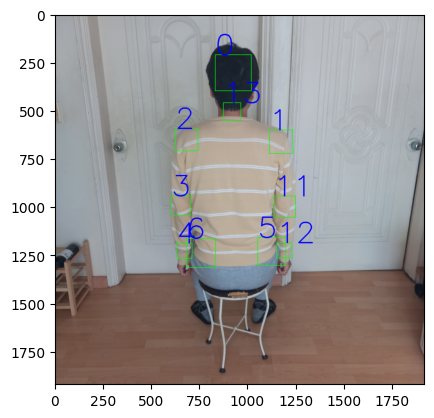

In [30]:
img = img.permute(1, 2, 0)
img = cv2.cvtColor(img.numpy(), cv2.COLOR_BGR2RGB)
# print(data)
for box in data:
    class_id, x1, y1, x2, y2 = box
    cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
plt.imshow(img)


In [31]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

def collate_fn(batch):
    img = [item[0] for item in batch]
    boxes = [item[1] for item in batch]
    max_boxes = max([len(box) for box in boxes])
    print(boxes[0].shape)
    print(max_boxes)
    boxes_list_padded = []
    for box in boxes:
        if box.shape[0] < max_boxes:
            box = torch.cat([box, torch.zeros(max_boxes - box.shape[0], 5)])
        boxes_list_padded.append(box)
    return torch.stack(img), torch.stack(boxes_list_padded)


dataset = backDataset()
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [32]:
test_train_img, test_train_data = next(iter(train_loader))
print(test_train_img.shape)

torch.Size([14, 5])
14
torch.Size([10, 3, 1920, 1920])


In [33]:
test_train_img = test_train_img.permute(0, 2, 3, 1)

In [34]:
test_train_data[4][0]

tensor([   0.0000, 1002.5154,  165.6259, 1166.3250,  329.4355])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


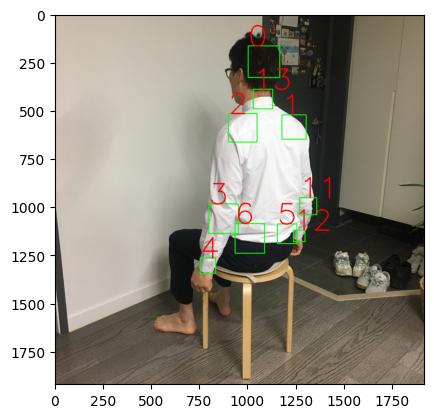

In [35]:
# plt.imshow(test_train_img[0].numpy())
img = cv2.cvtColor(test_train_img[4].numpy(), cv2.COLOR_BGR2RGB)
data = test_train_data[4]
for box in data:
    class_id, x1, y1, x2, y2 = box
    cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 3)
    cv2.putText(img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 5, (255, 0, 0), 5)
plt.imshow(img)

# YOLO
Yolov3 (might be easier)
https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/
https://arxiv.org/abs/1804.02767

Yolov7 (i can see why they said it's really complex lol)
https://www.plugger.ai/blog/yolov7-architecture-explanation  
https://blog.roboflow.com/yolov7-breakdown/
https://arxiv.org/abs/2207.02696
https://www.youtube.com/watch?v=zEXiGAPGKFk
https://www.youtube.com/watch?v=0p3Xk3iz-J4
https://www.youtube.com/watch?v=zhFmaU9LBus
https://blog.roboflow.com/yolov6/
https://learnopencv.com/yolov6-object-detection/

EELAN (Backbone)
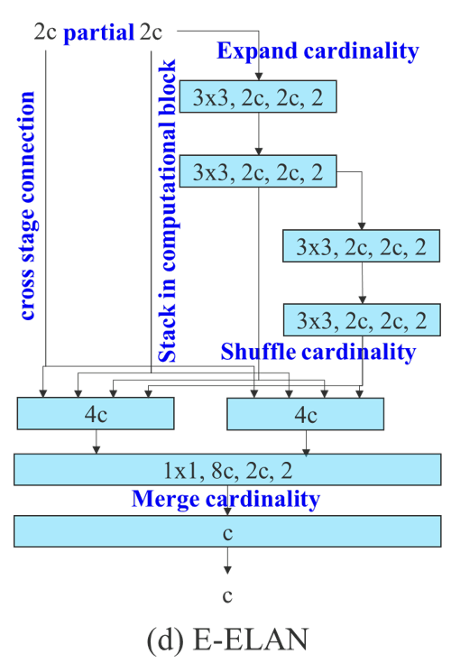

In [ ]:
class EELAN():
    def __init__(self):
        pass
    
    def forward(self, x):
        out
        return out

In [ ]:
class YOLO():
    def __init__(self):
        pass
    
    def forward(self, x):
        # Backbone
        
        pass